# Cross-Attention from Scratch

Self-attention lets a sequence talk to itself — every token queries every token in the **same** sequence. Cross-attention breaks that symmetry: queries come from one sequence, keys and values come from **another**.

$$\text{CrossAttention}(X_q, X_{kv}) = \text{softmax}\!\left(\frac{Q\,K^\top}{\sqrt{d_k}}\right)V$$

where $Q = X_q W_Q$, $\;K = X_{kv} W_K$, $\;V = X_{kv} W_V$.

| Symbol | Shape | Description |
|--------|-------|-------------|
| $X_q$ | $(\text{batch},\, \text{seq\_q},\, d_{\text{model}})$ | **Query source** — e.g. decoder hidden states |
| $X_{kv}$ | $(\text{batch},\, \text{seq\_kv},\, d_{\text{model}})$ | **Key/value source** — e.g. encoder output |
| $Q$ | $(\text{batch},\, \text{seq\_q},\, d_k)$ | Queries projected from $X_q$ |
| $K, V$ | $(\text{batch},\, \text{seq\_kv},\, d_k)$ | Keys and values projected from $X_{kv}$ |
| Weights | $(\text{batch},\, \text{seq\_q},\, \text{seq\_kv})$ | **Rectangular** — not square like self-attention |
| Output | $(\text{batch},\, \text{seq\_q},\, d_k)$ | One context vector per query token |

> **The attention matrix is rectangular.** Self-attention produces a $(\text{seq\_len} \times \text{seq\_len})$ square matrix. Cross-attention produces $(\text{seq\_q} \times \text{seq\_kv})$ — the two sequences can have different lengths.

## 1. Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

## 2. Self-Attention vs. Cross-Attention

The only structural change: **split the input into two streams.**

| | Self-Attention | Cross-Attention |
|---|---|---|
| Q source | $X$ | $X_q$ (decoder) |
| K, V source | $X$ (same) | $X_{kv}$ (encoder) |
| Scores shape | $(\text{batch},\, T,\, T)$ — square | $(\text{batch},\, T_q,\, T_{kv})$ — rectangular |
| Causal mask | Common (GPT) | Rare — decoder sees full encoder output |
| Use case | Token-to-token within one sequence | Decoder token → encoder token alignment |

> [diagram: Self-attention vs cross-attention data flow
> 
> Self-Attention:
> Input: x — [batch, seq_len, d_model]
> → W_Q, W_K, W_V all applied to x
> → scores — [batch, seq_len, seq_len] (square)
> 
> Cross-Attention:
> Input 1: x_q — [batch, seq_q, d_model] → W_Q → Q
> Input 2: x_kv — [batch, seq_kv, d_model] → W_K, W_V → K, V
> → scores — [batch, seq_q, seq_kv] (rectangular)
> ]

- `W_Q` projects the **query** sequence — "what am I looking for?"
- `W_K`, `W_V` project the **context** sequence — "what can I attend to?"
- `torch.bmm(Q, K.T)` produces a rectangular matrix because `seq_q ≠ seq_kv` in general.

## 3. Implementing Cross-Attention

**Forward pass steps:**
1. Project $X_q \to Q$ and $X_{kv} \to K, V$ via separate linear layers
2. Compute scores: $S = QK^\top / \sqrt{d_k}$ — shape `(batch, seq_q, seq_kv)`
3. *(Optional)* Apply a padding mask to ignore `<pad>` tokens in the encoder output
4. Softmax over the **key dimension** (`dim=-1`)
5. Weighted sum: $\text{out} = AV$ — shape `(batch, seq_q, d_k)`

In [2]:
class CrossAttention(nn.Module):
    """
    Scaled dot-product cross-attention.

    Queries come from x_q (e.g. decoder), keys and values from x_kv
    (e.g. encoder output). Produces a rectangular attention matrix
    of shape (batch, seq_q, seq_kv).

    CrossAttention(X_q, X_kv) = softmax(Q K^T / sqrt(d_k)) V
    where Q = X_q W_Q,  K = X_kv W_K,  V = X_kv W_V
    """

    def __init__(self, d_model: int, d_k: int | None = None):
        """
        Args:
            d_model: Dimensionality of both input sequences.
            d_k:     Key/query/value projection dimension. Defaults to d_model.
        """
        super().__init__()
        self.d_k = d_k if d_k is not None else d_model

        self.W_q = nn.Linear(d_model, self.d_k, bias=False)  # projects query sequence
        self.W_k = nn.Linear(d_model, self.d_k, bias=False)  # projects key/value sequence
        self.W_v = nn.Linear(d_model, self.d_k, bias=False)  # projects key/value sequence

    def forward(
        self,
        x_q: torch.Tensor,
        x_kv: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x_q:  Query input,     shape (batch, seq_q, d_model).
            x_kv: Key/value input, shape (batch, seq_kv, d_model).
            mask:  Optional boolean mask, shape (seq_q, seq_kv) or (batch, seq_q, seq_kv).
                   True positions are masked out (set to -inf before softmax).

        Returns:
            out:     Context vectors, shape (batch, seq_q, d_k).
            weights: Attention weights, shape (batch, seq_q, seq_kv).
        """
        Q = self.W_q(x_q)    # (batch, seq_q,  d_k)
        K = self.W_k(x_kv)   # (batch, seq_kv, d_k)
        V = self.W_v(x_kv)   # (batch, seq_kv, d_k)

        # Rectangular scores: (batch, seq_q, seq_kv)
        scores = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))

        weights = F.softmax(scores, dim=-1)  # (batch, seq_q, seq_kv)
        out = torch.bmm(weights, V)          # (batch, seq_q, d_k)
        return out, weights

## 4. Sanity Check

Verify shapes with **different** sequence lengths for query and key/value — this is the whole point.

Decoder with `seq_q=4` tokens attending to encoder output with `seq_kv=6` tokens, `d_model=16`, `d_k=8`:

| Tensor | Expected shape |
|--------|---------------|
| Query input `x_q` | `(batch, seq_q, d_model)` = `(2, 4, 16)` |
| Key/value input `x_kv` | `(batch, seq_kv, d_model)` = `(2, 6, 16)` |
| Q | `(batch, seq_q, d_k)` = `(2, 4, 8)` |
| K, V | `(batch, seq_kv, d_k)` = `(2, 6, 8)` |
| Weights | `(batch, seq_q, seq_kv)` = `(2, 4, 6)` — **rectangular** |
| Output | `(batch, seq_q, d_k)` = `(2, 4, 8)` — matches query length |

In [3]:
torch.manual_seed(0)

batch, seq_q, seq_kv, d_model = 2, 4, 6, 16
x_q  = torch.randn(batch, seq_q,  d_model)  # decoder states
x_kv = torch.randn(batch, seq_kv, d_model)  # encoder output

cross_attn = CrossAttention(d_model=d_model, d_k=8)
out, weights = cross_attn(x_q, x_kv)

print(f"Query input shape  : {x_q.shape}")     # (2, 4, 16)
print(f"KV input shape     : {x_kv.shape}")    # (2, 6, 16)
print(f"Output shape       : {out.shape}")      # (2, 4, 8)
print(f"Weights shape      : {weights.shape}")  # (2, 4, 6) — rectangular!

# Each query row must sum to 1 (valid probability distribution over keys)
assert torch.allclose(weights.sum(dim=-1), torch.ones(batch, seq_q), atol=1e-6)
# All weights positive (no mask applied)
assert (weights > 0).all()

print(f"\nAll rows sum to 1, all weights positive — cross-attention confirmed.")
print(f"\nWeights (batch 0) — each decoder token's distribution over encoder tokens:")
print(weights[0].detach().round(decimals=3))

Query input shape  : torch.Size([2, 4, 16])
KV input shape     : torch.Size([2, 6, 16])
Output shape       : torch.Size([2, 4, 8])
Weights shape      : torch.Size([2, 4, 6])

All rows sum to 1, all weights positive — cross-attention confirmed.

Weights (batch 0) — each decoder token's distribution over encoder tokens:
tensor([[0.2130, 0.1210, 0.1380, 0.2180, 0.1910, 0.1190],
        [0.1300, 0.2230, 0.1430, 0.1320, 0.2160, 0.1560],
        [0.1290, 0.2120, 0.2050, 0.1170, 0.1760, 0.1610],
        [0.2380, 0.0760, 0.0780, 0.3670, 0.1230, 0.1170]])


## 5. Padding Mask

Unlike causal masking (upper-triangle → block future tokens), cross-attention typically uses a **padding mask** to ignore `<pad>` tokens in variable-length encoder outputs.

$$A_{ij} = \begin{cases} \text{softmax}_j\!\left(\dfrac{Q_i K_j^\top}{\sqrt{d_k}}\right) & \text{if } j \text{ is not padded} \\ 0 & \text{if } j \text{ is a pad token} \end{cases}$$

```python
# encoder tokens: ["The", "CEO", "announced", "<pad>", "<pad>"]
pad_positions = [False, False, False, True, True]
# Expand to (1, 1, seq_kv) → broadcasts over (batch, seq_q, seq_kv)
pad_mask = torch.tensor(pad_positions).unsqueeze(0).unsqueeze(0)
```

- The mask broadcasts along `dim=1` (seq_q) — every decoder token ignores the same padded encoder positions.
- Softmax redistributes probability mass to the non-padded tokens only.

In [4]:
torch.manual_seed(0)

# Decoder: 3 tokens, Encoder: 5 tokens (last 2 are padding)
batch, seq_q, seq_kv, d_model = 1, 3, 5, 16
x_q  = torch.randn(batch, seq_q,  d_model)
x_kv = torch.randn(batch, seq_kv, d_model)

# Padding mask: True at encoder positions 3 and 4
pad_positions = torch.tensor([False, False, False, True, True])  # (seq_kv,)
pad_mask = pad_positions.unsqueeze(0).unsqueeze(0)               # (1, 1, seq_kv) — broadcasts

cross_attn = CrossAttention(d_model=d_model, d_k=8)
out_pad, weights_pad = cross_attn(x_q, x_kv, mask=pad_mask)

print(f"Weights shape: {weights_pad.shape}")  # (1, 3, 5)
print(f"\nWeights with padding mask:")
print(weights_pad[0].detach().round(decimals=3))

# Padded columns (indices 3, 4) must be zero
assert (weights_pad[:, :, 3:] < 1e-9).all(), "Padded positions must have zero weight"
# Rows still sum to 1
assert torch.allclose(weights_pad.sum(dim=-1), torch.ones(batch, seq_q), atol=1e-6)
print("\nPadded positions zeroed out, rows still sum to 1.")

Weights shape: torch.Size([1, 3, 5])

Weights with padding mask:
tensor([[0.3000, 0.2460, 0.4540, 0.0000, 0.0000],
        [0.4000, 0.3080, 0.2920, 0.0000, 0.0000],
        [0.2770, 0.3900, 0.3330, 0.0000, 0.0000]])

Padded positions zeroed out, rows still sum to 1.


## 6. Visualization — Translation Alignment

Cross-attention in translation: the decoder query tokens (target language) attend to the encoder key tokens (source language). The weight matrix reveals the **word alignment** the model learns.

| Axis | Represents |
|------|------------|
| y-axis (rows) | Decoder / query tokens — "what am I looking for?" |
| x-axis (cols) | Encoder / key tokens — "what can I attend to?" |
| Cell value | How much decoder token $i$ attends to encoder token $j$ |

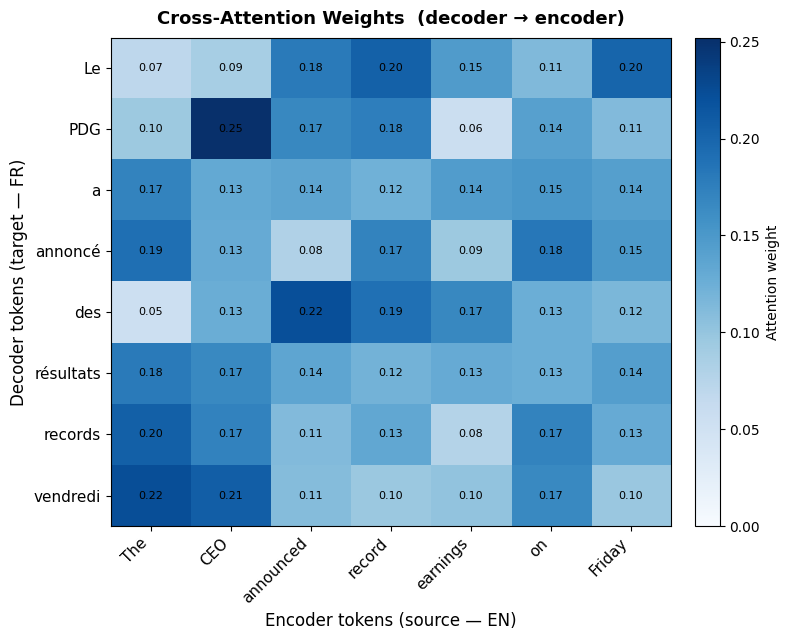

In [5]:
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Simulate EN → FR translation alignment
encoder_tokens = ["The", "CEO", "announced", "record", "earnings", "on", "Friday"]   # source (EN)
decoder_tokens = ["Le", "PDG", "a", "annoncé", "des", "résultats", "records", "vendredi"]  # target (FR)

seq_kv  = len(encoder_tokens)
seq_q   = len(decoder_tokens)
d_model = 16

x_q  = torch.randn(1, seq_q,  d_model)
x_kv = torch.randn(1, seq_kv, d_model)

cross_attn = CrossAttention(d_model=d_model, d_k=8)
_, weights = cross_attn(x_q, x_kv)
w = weights[0].detach().numpy()  # (seq_q, seq_kv) — rectangular

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(w, vmin=0, vmax=w.max(), cmap="Blues", aspect="auto")

ax.set_xticks(range(seq_kv))
ax.set_yticks(range(seq_q))
ax.set_xticklabels(encoder_tokens, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(decoder_tokens, fontsize=11)
ax.set_xlabel("Encoder tokens (source — EN)", fontsize=12)
ax.set_ylabel("Decoder tokens (target — FR)", fontsize=12)
ax.set_title("Cross-Attention Weights  (decoder → encoder)",
             fontsize=13, fontweight="bold", pad=10)

for i in range(seq_q):
    for j in range(seq_kv):
        ax.text(j, i, f"{w[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if w[i, j] > 0.4 else "black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Attention weight")
plt.tight_layout()
plt.show()

## 7. Where Cross-Attention Appears

| Architecture | Query source | Key/Value source | Purpose |
|---|---|---|---|
| **Transformer decoder** (original) | Decoder hidden states | Encoder output | Each generated token attends to the full source sentence |
| **Stable Diffusion** | Denoising U-Net features | CLIP text embeddings | Image features attend to text prompt tokens |
| **Whisper** | Text decoder states | Audio encoder output | Each text token aligns to audio frames |
| **Vision-Language models** | Text tokens | Image patch embeddings | Text attends to visual regions |

In all cases the pattern is identical: **one sequence asks questions** ($Q$), **another sequence provides answers** ($K, V$).

> **Gotchas**
> - Both sequences must share the same `d_model` (or use separate projection dimensions). The projection matrices handle the rest.
> - Cross-attention weight matrices are **not symmetric** — row $i$ attending heavily to column $j$ does not imply the reverse.
> - No causal mask is typical — the decoder sees the **entire** encoder output at every step. Autoregressive masking happens in the decoder's **self-attention** layer, not in cross-attention.